In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

In [2]:
df = pd.read_csv('diamonds.csv')

In [3]:
df = df.rename(columns={
    'x': 'length',
    'y': 'width',
    'z': 'depth_mm',
})

In [4]:
df

,carat,cut,color,clarity,depth,table,price,length,width,depth_mm
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
49995,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
49996,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
49997,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
49998,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [5]:
df['ln_price'] = np.log(df['price'])
df['ln_carat'] = np.log(df['carat'])
df['volume'] = df['length'] * df['width'] * df['depth_mm']

In [6]:
print(df['color'].unique())
print(df['cut'].unique())
print(df['clarity'].unique())

['E' 'I' 'J' 'H' 'F' 'G' 'D']
['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   carat     50000 non-null  float64
 1   cut       50000 non-null  object 
 2   color     50000 non-null  object 
 3   clarity   50000 non-null  object 
 4   depth     50000 non-null  float64
 5   table     50000 non-null  float64
 6   price     50000 non-null  int64  
 7   length    50000 non-null  float64
 8   width     50000 non-null  float64
 9   depth_mm  50000 non-null  float64
 10  ln_price  50000 non-null  float64
 11  ln_carat  50000 non-null  float64
 12  volume    50000 non-null  float64
dtypes: float64(9), int64(1), object(3)
memory usage: 5.0+ MB


In [8]:
desc = df.describe().T.round(2)
desc.to_html("desc_stat.html")

In [9]:
desc

,count,mean,std,min,25%,50%,75%,max
carat,50000.0,0.80,0.48,0.20,0.40,0.70,1.04,5.01
depth,50000.0,61.75,1.43,43.00,61.00,61.80,62.50,79.00
table,50000.0,57.46,2.23,43.00,56.00,57.00,59.00,95.00
price,50000.0,3944.81,3997.94,326.00,951.00,2410.00,5351.00,18823.00
length,50000.0,5.73,1.12,0.00,4.71,5.70,6.54,10.74
width,50000.0,5.74,1.15,0.00,4.72,5.71,6.54,58.90
depth_mm,50000.0,3.54,0.71,0.00,2.91,3.53,4.04,31.80
ln_price,50000.0,7.79,1.02,5.79,6.86,7.79,8.59,9.84
ln_carat,50000.0,-0.39,0.59,-1.61,-0.92,-0.36,0.04,1.61
volume,50000.0,130.11,78.56,0.00,65.22,114.94,171.01,3840.60


In [10]:
desc_cat = df.describe(include=['object', 'category'])
desc_cat.to_html("desc_cat_stat.html")

In [11]:
desc_cat

,cut,color,clarity
count,50000,50000,50000
unique,5,7,8
top,Ideal,G,SI1
freq,19938,10452,12115


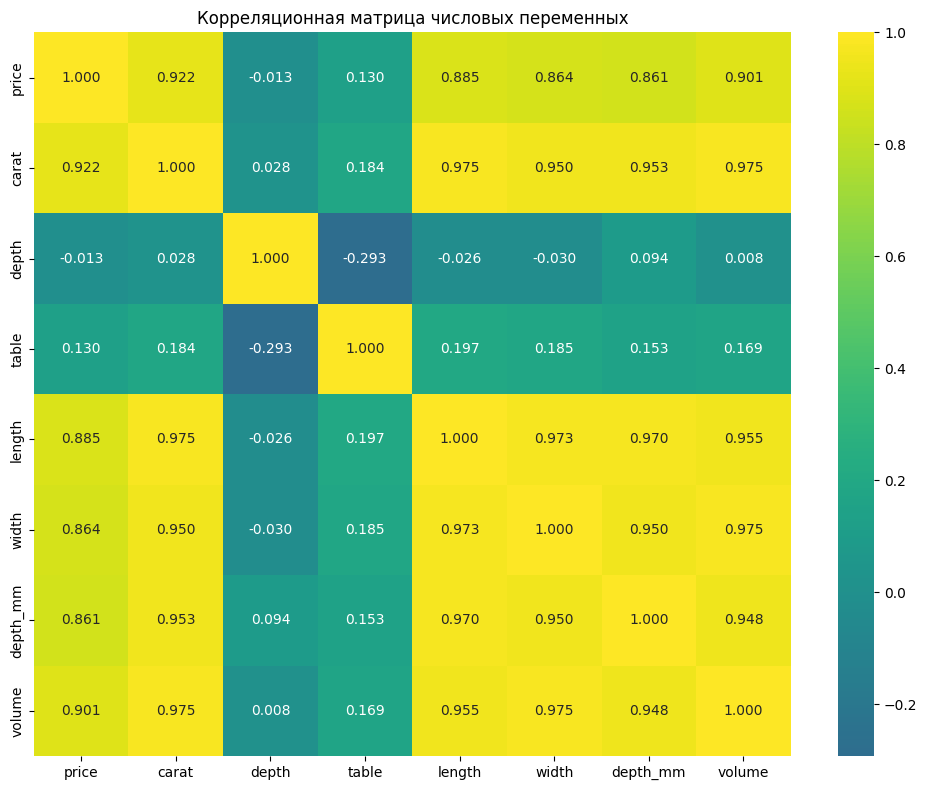

In [12]:
numeric_cols = [
    'price', 'carat', 'depth', 'table',
    'length', 'width', 'depth_mm', 'volume'
]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    center=0
)

plt.title("Корреляционная матрица числовых переменных")
plt.tight_layout()
plt.savefig("corr_matrix.jpg", bbox_inches="tight")
plt.show()
plt.close()


In [13]:
df[numeric_cols].corr().round(3).to_html("corr_matrix.html")

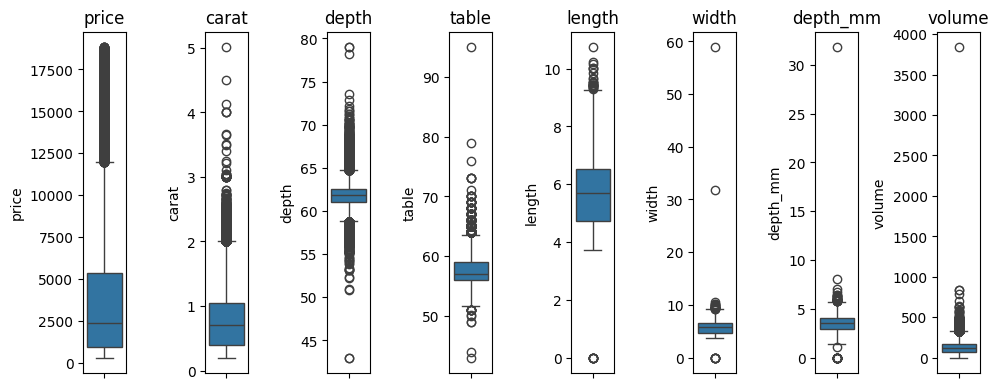

In [14]:
fig, axes = plt.subplots(1, 8, figsize=(10, 4))
axes = axes.flatten()

for i, var in enumerate(numeric_cols):
    sns.boxplot(y=df[var], ax=axes[i])
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.savefig("boxplots_numeric.jpg", bbox_inches="tight")
plt.show()

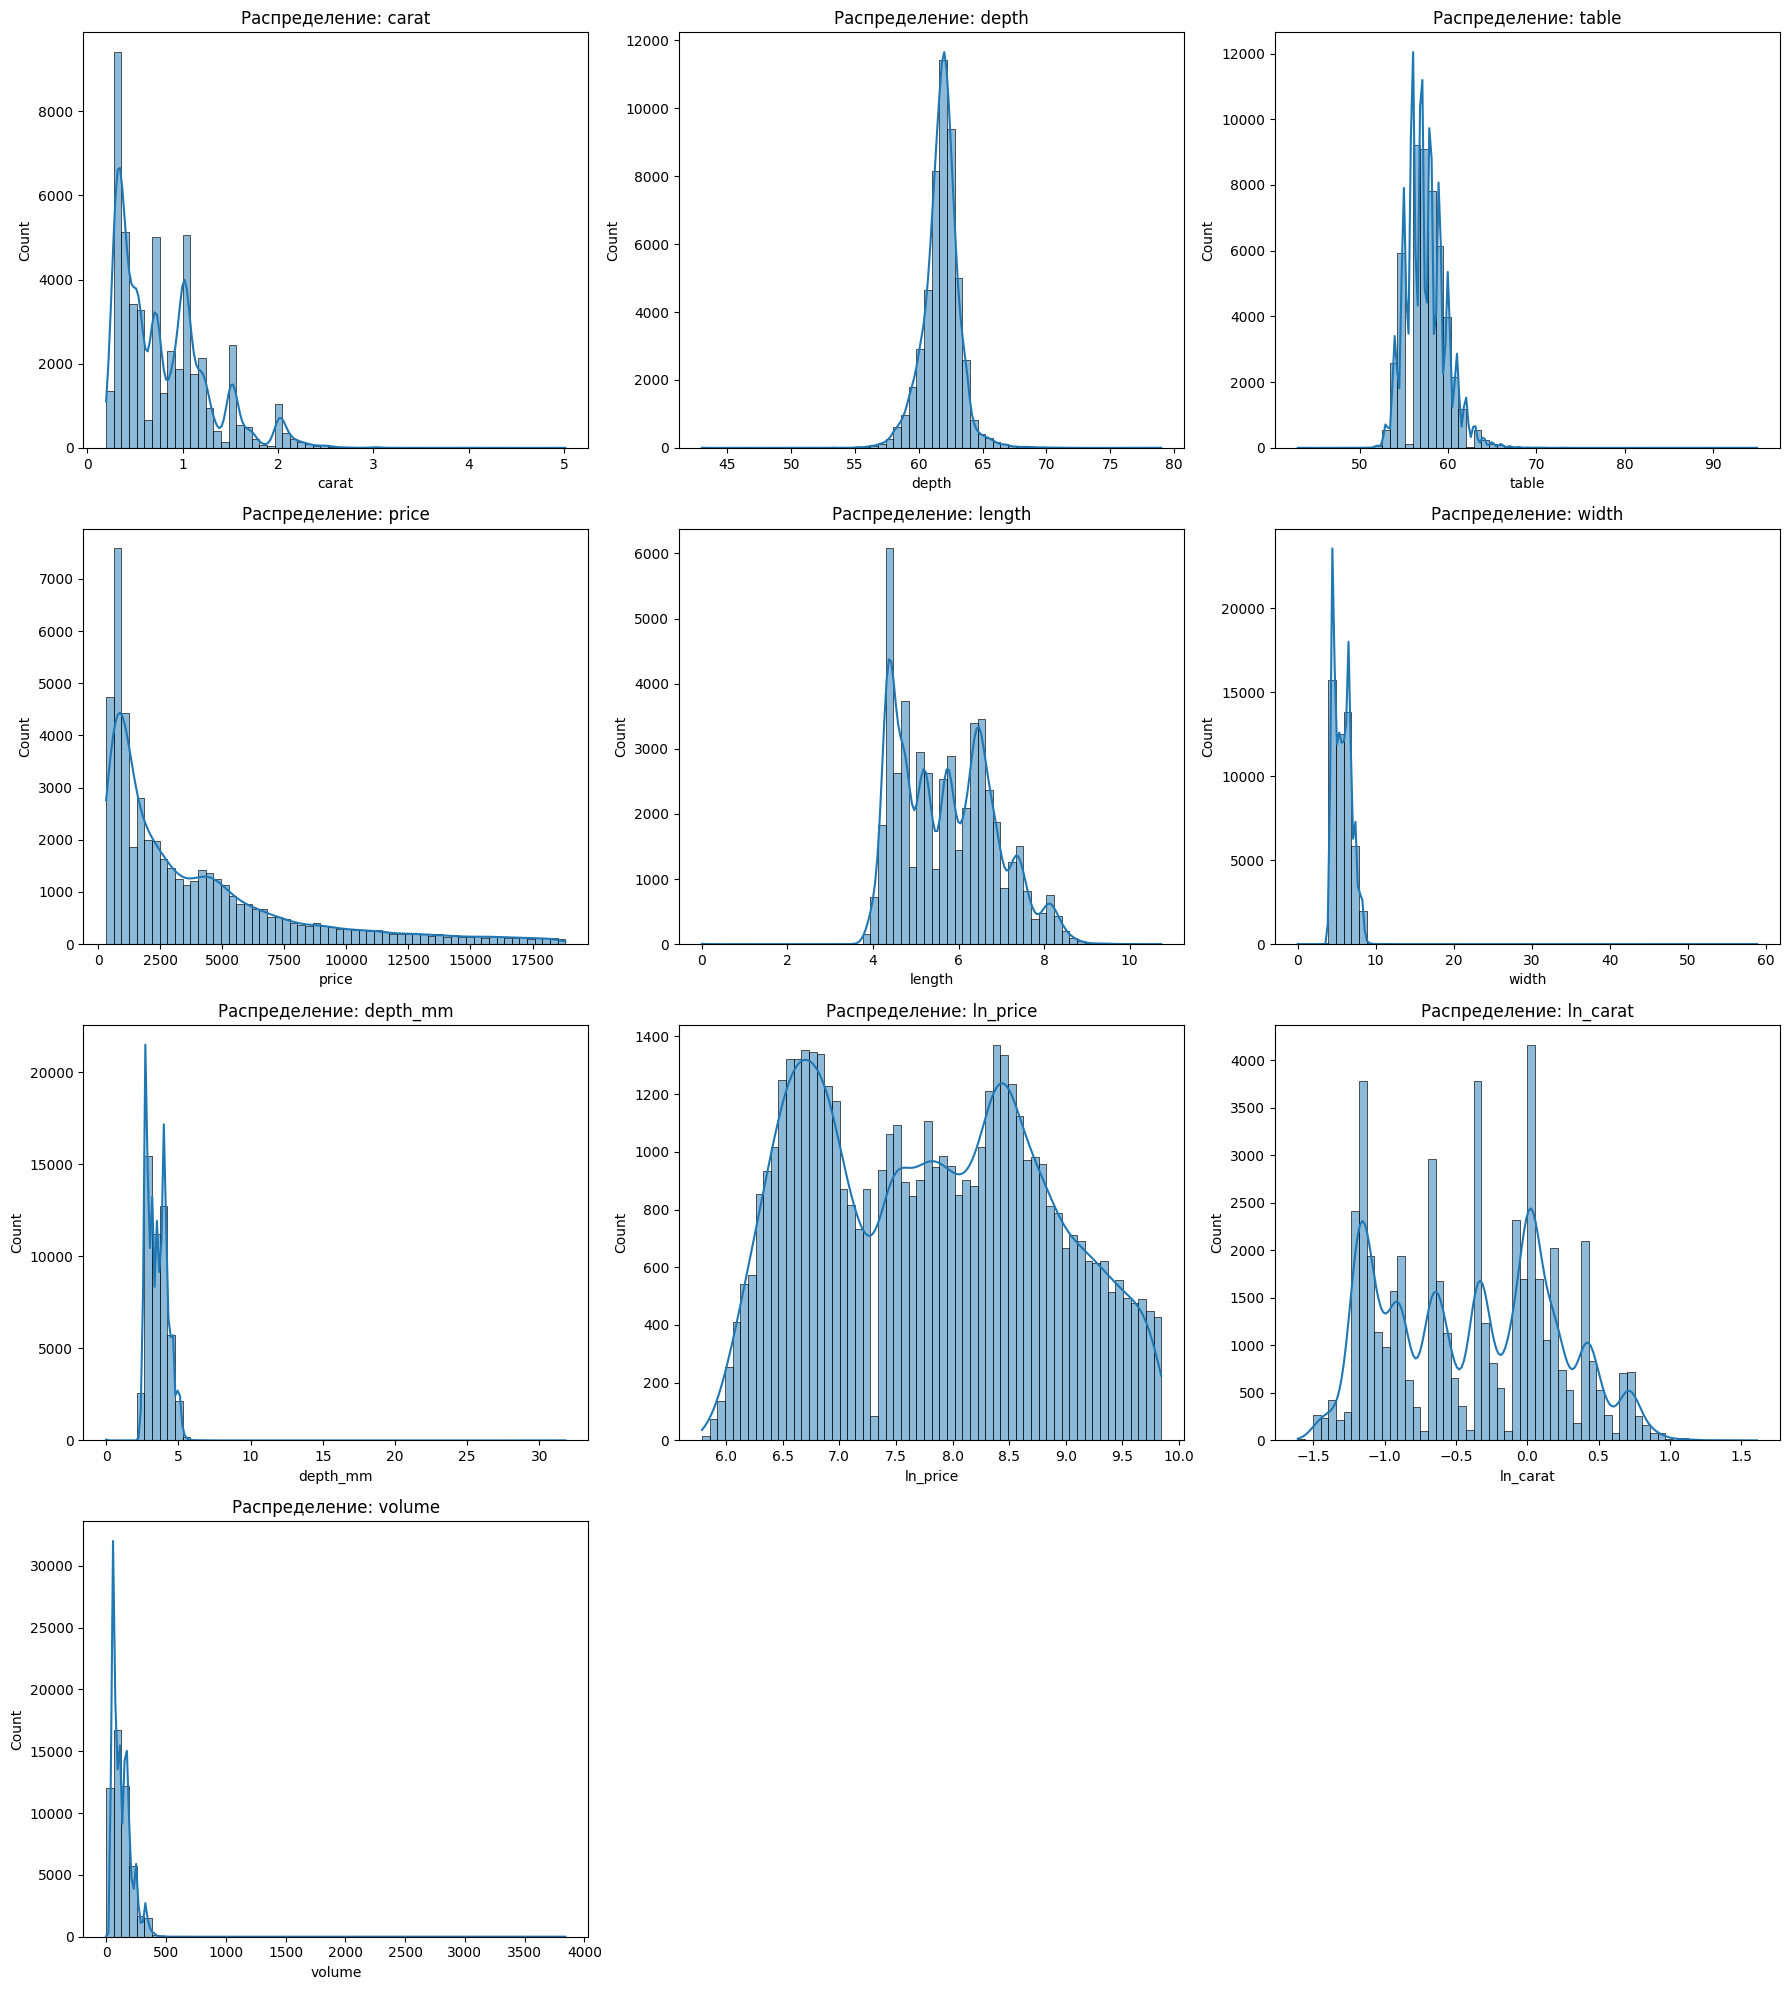

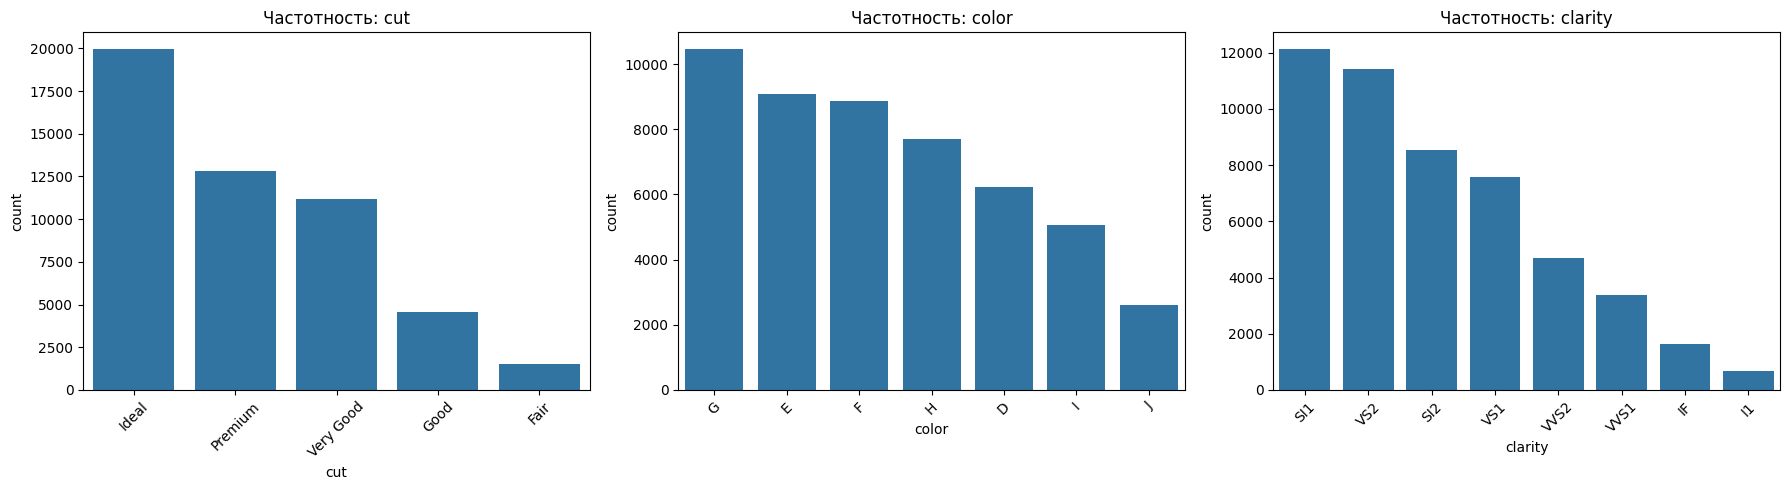

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

n_num = len(numeric_cols)
rows_num = (n_num + 2) // 3

fig, axes = plt.subplots(rows_num, 3, figsize=(18, 5 * rows_num))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=60, kde=True, ax=axes[i])
    axes[i].set_title(f"Распределение: {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("distributions_num.jpg", bbox_inches="tight")
plt.show()

n_cat = len(categorical_cols)
rows_cat = (n_cat + 2) // 3

fig, axes = plt.subplots(rows_cat, 3, figsize=(18, 5 * rows_cat))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i],
                  order=df[col].value_counts().index)
    axes[i].set_title(f"Частотность: {col}")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("distributions_cat.jpg", bbox_inches="tight")
plt.show()


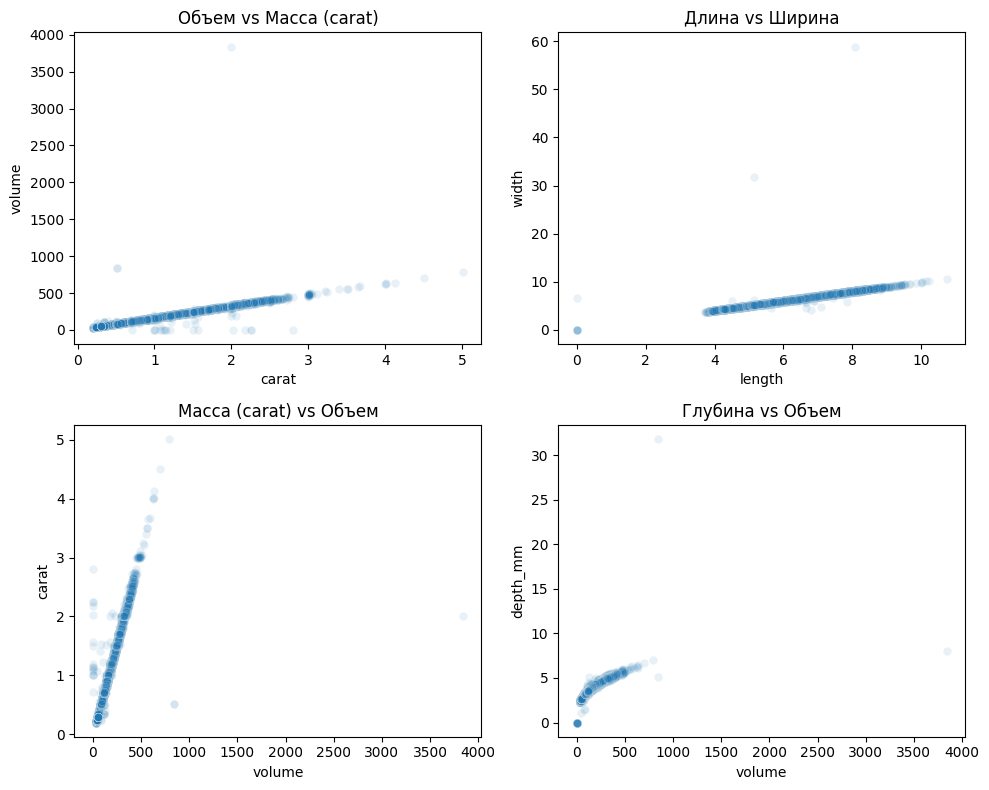

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.scatterplot(data=df, x='carat', y='volume', alpha=0.1, ax=axes[0,0])
axes[0,0].set_title('Объем vs Масса (carat)')

sns.scatterplot(data=df, x='length', y='width', alpha=0.1, ax=axes[0,1])
axes[0,1].set_title('Длина vs Ширина')

sns.scatterplot(data=df, x='volume', y='carat', alpha=0.1, ax=axes[1,0])
axes[1,0].set_title('Масса (carat) vs Объем')

sns.scatterplot(data=df, x='volume', y='depth_mm', alpha=0.1, ax=axes[1,1])
axes[1,1].set_title('Глубина vs Объем')

plt.tight_layout()
plt.savefig("connections.jpg", bbox_inches="tight")
plt.show()

In [17]:
zero_dimensions = df[(df['length'] == 0) | (df['width'] == 0) | (df['depth_mm'] == 0)]
zero_dimensions.shape

(17, 13)

In [18]:
df = df[(df['length'] != 0) & (df['width'] != 0) & (df['depth_mm'] != 0)]

In [19]:
df.duplicated().sum()

np.int64(126)

In [20]:
df[df.duplicated()].head()

,carat,cut,color,clarity,depth,table,price,length,width,depth_mm,ln_price,ln_carat,volume
918,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,7.971776,-0.235722,126.324900
919,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,7.971776,-0.235722,126.324900
920,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,7.971776,-0.235722,126.324900
921,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66,7.971776,-0.235722,126.324900
1871,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28,8.040769,0.418710,239.134728


In [21]:
df[df.duplicated(subset=['carat', 'cut', 'color', 'clarity', 'price'])].head()

,carat,cut,color,clarity,depth,table,price,length,width,depth_mm,ln_price,ln_carat,volume
18,0.30,Good,J,SI1,63.8,56.0,351,4.23,4.26,2.71,5.860786,-1.203973,48.833658
23,0.31,Very Good,J,SI1,58.1,62.0,353,4.44,4.47,2.59,5.866468,-1.171183,51.403212
30,0.23,Very Good,F,VS1,59.8,57.0,402,4.04,4.06,2.42,5.996452,-1.469676,39.693808
32,0.23,Very Good,E,VS1,59.5,58.0,402,4.01,4.06,2.40,5.996452,-1.469676,39.073440
39,0.33,Ideal,I,SI2,61.2,56.0,403,4.49,4.50,2.75,5.998937,-1.108663,55.563750


In [22]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.duplicated().sum())
df.shape

0


(49857, 13)

### Гипотеза 1: Ценовая функция драгоценных камней характеризуется наличием порогового эффекта (Threshold effect) по массе. Иными словами, эта функция не является непрерывной по каратам.

In [23]:
import numpy as np

# Окна вокруг пороговых значений: 0.5, 1.0, 1.5, 2.0
conditions = [
    ((df['carat'] >= 0.48) & (df['carat'] <= 0.52)),   # вокруг 0.5
    ((df['carat'] >= 0.98) & (df['carat'] <= 1.02)),   # вокруг 1.0
    ((df['carat'] >= 1.48) & (df['carat'] <= 1.52)),   # вокруг 1.5
    ((df['carat'] >= 1.98) & (df['carat'] <= 2.02)),   # вокруг 2.0
]

df['is_Threshold'] = np.select(conditions, [1]*len(conditions), default=0).astype(int)

print(df['is_Threshold'].value_counts())

is_Threshold
0    39729
1    10128
Name: count, dtype: int64


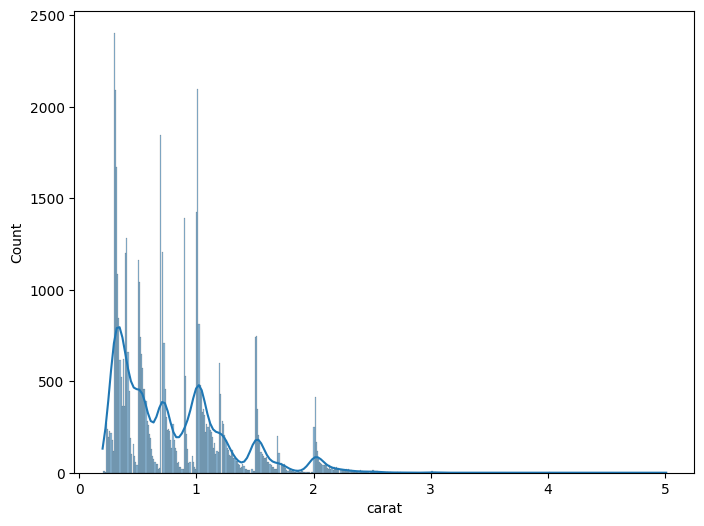

In [24]:
plt.figure(figsize=(8, 6))
sns.histplot(df['carat'], bins=500, kde=True)

plt.savefig("carat_hist.jpg", bbox_inches="tight", dpi=300)
plt.show()

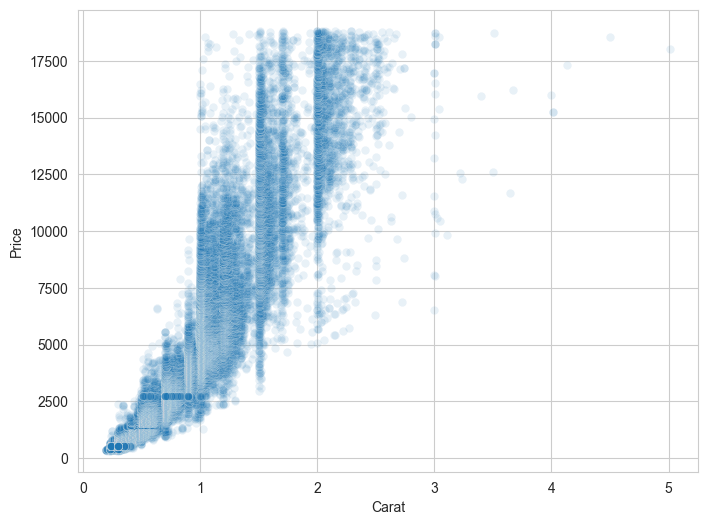

In [45]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.1)

plt.xlabel('Carat')
plt.ylabel('Price')
plt.savefig("price_carat_scatter.jpg", bbox_inches="tight", dpi=300)
plt.show()

In [25]:
df_dum = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

X_cols = ['ln_carat', 'depth', 'table', 'is_Threshold'] \
         + [col for col in df_dum.columns if col.startswith('cut_')] \
         + [col for col in df_dum.columns if col.startswith('color_')] \
         + [col for col in df_dum.columns if col.startswith('clarity_')]

X = df_dum[X_cols]
X = X.astype(float)
y = df_dum['ln_price']
X = sm.add_constant(X)

model_manual = sm.OLS(y, X).fit(cov_type='HC3')
model_manual.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.146e+05
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:22:35   Log-Likelihood:                 30346.
No. Observations:               49857   AIC:                        -6.065e+04
Df Residuals:                   49835   BIC:                        -6.045e+04
Df Model:                          21                                         
Covariance Type:                  HC3                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.0246      0.053    150.370      0.000       7.920       8.129
ln_carat          1.8724      0.001   1361.974      0.000       1.870       1.875
depth            -0.0021      0.001     -3.467      0.001      -0.003      -0.001
table            -0.0010      0.000     -2.759      0.006      -0.002      -0.000
is_Threshold      0.0592      0.001     42.171      0.000       0.056       0.062
cut_Good          0.0829      0.005     16.716      0.000       0.073       0.093
cut_Ideal         0.1688      0.005     33.170      0.000       0.159       0.179
cut_Premium       0.1459      0.005     29.274      0.000       0.136       0.156
cut_Very Good     0.1230      0.005     25.104      0.000       0.113       0.133
color_E          -0.0545      0.002    -23.558      0.000      -0.059      -0.050
color_F          -0.0937      0.002    -39.801      0.000      -0.098      -0.089
color_G          -0.1585      0.002    -68.727      0.000      -0.163      -0.154
color_H          -0.2464      0.002   -102.266      0.000      -0.251      -0.242
color_I          -0.3659      0.003   -135.492      0.000      -0.371      -0.361
color_J          -0.5040      0.003   -147.934      0.000      -0.511      -0.497
clarity_IF        1.1065      0.010    114.993      0.000       1.088       1.125
clarity_SI1       0.5861      0.009     66.955      0.000       0.569       0.603
clarity_SI2       0.4233      0.009     47.941      0.000       0.406       0.441
clarity_VS1       0.8057      0.009     91.362      0.000       0.788       0.823
clarity_VS2       0.7333      0.009     83.559      0.000       0.716       0.750
clarity_VVS1      1.0133      0.009    111.149      0.000       0.995       1.031
clarity_VVS2      0.9393      0.009    104.451      0.000       0.922       0.957
==============================================================================
Omnibus:                     3547.746   Durbin-Watson:                   1.249
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14809.384
Skew:                           0.240   Prob(JB):                         0.00
Kurtosis:                       5.627   Cond. No.                     6.40e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 6.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

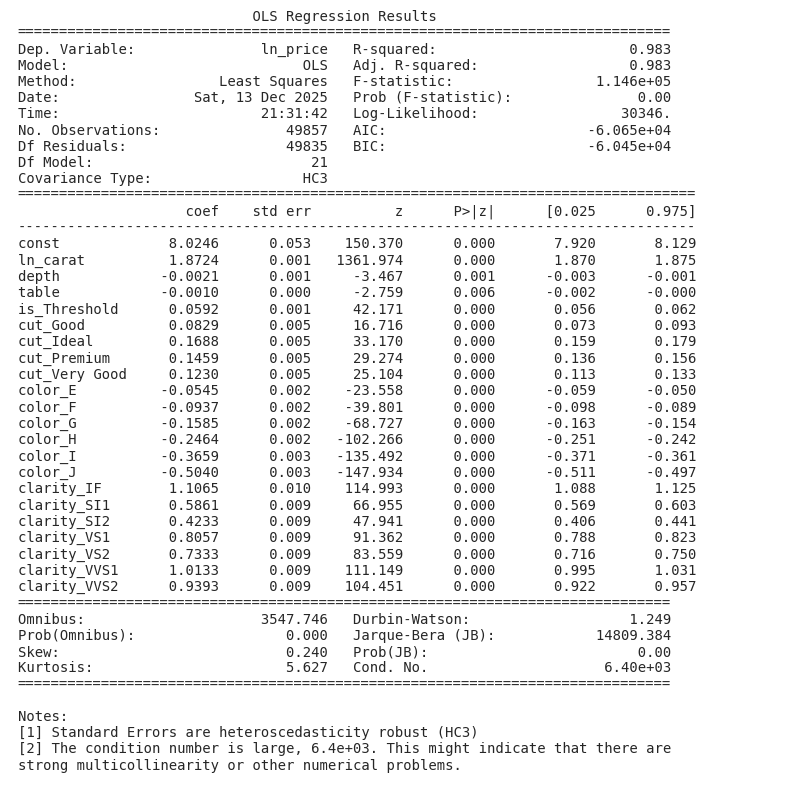

In [35]:
plt.figure(figsize=(10, 6))
plt.text(0.01, 0.05, model_manual.summary().as_text(), fontfamily='monospace')
plt.axis('off')
plt.savefig("ols_results.png", dpi=300, bbox_inches="tight")
plt.show()

*Гипотеза не отвергается. Коэффициент $\beta = 1.8724$ > $1$.*

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["var"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif)

plt.figure(figsize=(8, 0.4 * len(vif) + 1))
plt.axis("off")
plt.table(
    cellText=vif.round(3).values,
    colLabels=vif.columns,
    loc="center",
    cellLoc="left"
)
plt.savefig("vif_table.png", dpi=300, bbox_inches="tight")
plt.close()

,var,VIF
0,const,"5,710.9229"
1,ln_carat,1.3256
2,depth,1.3866
3,table,1.7915
4,cut_Good,3.9613
5,cut_Ideal,11.3925
6,cut_Premium,8.4231
7,cut_Very Good,7.6847
8,color_E,2.0210
9,color_F,2.0252


### Гипотеза 2. В премиум сегменте (price > 8000$) цена стимулирует покупателей к демонстративному потреблению по Торстейну Веблену, и при прочих равных покупатели готовы платить больше.

In [27]:
pd.options.display.float_format = '{:,.4f}'.format

df_veblen = df.copy()

PRICE_THRESHOLD = 8000
df_veblen['is_premium'] = (df_veblen['price'] > PRICE_THRESHOLD).astype(int)

cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
df_veblen['cut_code'] = df_veblen['cut'].map(cut_map)

color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
df_veblen['color_code'] = df_veblen['color'].map(color_map)

clarity_map = {
    'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4,
    'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8
}
df_veblen['clarity_code'] = df_veblen['clarity'].map(clarity_map)

features = [
    'ln_carat',
    'depth',
    'table',
    'cut_code',
    'color_code',
    'clarity_code',
    'is_premium'
]

df_model = df_veblen.dropna(subset=features + ['ln_price'])

X = df_model[features]
Y = df_model['ln_price']

X = sm.add_constant(X)

print(f"Количество наблюдений: {len(df_model)}")
print(f"Количество независимых переменных: {len(features)}")

model = sm.OLS(Y, X)
results = model.fit(cov_type='HC3')

beta_premium = results.params['is_premium']
p_val = results.pvalues['is_premium']

Количество наблюдений: 49857
Количество независимых переменных: 7


In [40]:
summary = results.summary()

display(summary)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.text(0.01, 0.05, summary.as_text(), fontfamily="monospace")
plt.axis("off")
plt.savefig("veblen_ols_summary.png", dpi=300, bbox_inches="tight")
plt.close()

print(f"beta_premium = {beta_premium:.4f}")
print(f"p_value = {p_val:.4g}")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                 2.662e+05
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:37:31   Log-Likelihood:                 25808.
No. Observations:               49857   AIC:                        -5.160e+04
Df Residuals:                   49849   BIC:                        -5.153e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.8249      0.057    137.656      0.000       7.713       7.936
ln_carat         1.8424      0.002   1018.017      0.000       1.839       1.846
depth           -0.0038      0.001     -5.653      0.000      -0.005      -0.002
table           -0.0004      0.000     -0.915      0.360      -0.001       0.000
cut_code         0.0290      0.001     38.291      0.000       0.027       0.030
color_code       0.0769      0.000    189.236      0.000       0.076       0.078
clarity_code     0.1186      0.001    235.825      0.000       0.118       0.120
is_premium       0.0834      0.002     33.446      0.000       0.078       0.088
==============================================================================
Omnibus:                     3709.233   Durbin-Watson:                   1.270
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13831.266
Skew:                          -0.312   Prob(JB):                         0.00
Kurtosis:                       5.504   Cond. No.                     6.21e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 6.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

beta_premium = 0.0834
p_value = 2.936e-245


*$\beta = 0.0834$ > 0 и эффект Веблена, действительно, присутсвует.*

In [29]:
if p_val < 0.05:
    significance = "статистически значим"
    if beta_premium > 0:
        conclusion = "гипотеза подтверждена."
        premium_pct = (np.exp(beta_premium) - 1) * 100
        desc = (
            f"При прочих равных,\n"
            f"камни в сегменте >${PRICE_THRESHOLD} стоят на {premium_pct:.2f}% дороже.\n"
            f"Это подтверждает наличие статусной премии."
        )
    else:
        conclusion = "гипотеза отвергнута"
        desc = (
            f"Коэффициент отрицательный ({beta_premium:.4f}). "
            "В высоком ценовом сегменте наценка ниже ожидаемой."
        )
else:
    significance = "незначим"
    conclusion = "гипотеза не подтверждена."
    desc = (
        "Статистически значимой разницы в ценообразовании "
        "для дорогого сегмента не найдено."
    )

print(f"Коэффициент is_premium: {beta_premium:.4f}")
print(f"P-value:                {p_val:.4e} ({significance})")
print(conclusion)
print(desc)

Коэффициент is_premium: 0.0834
P-value:                2.9356e-245 (статистически значим)
гипотеза подтверждена.
При прочих равных,
камни в сегменте >$8000 стоят на 8.69% дороже.
Это подтверждает наличие статусной премии.


### Гипотеза 3. Ценовая функция бриллиантов является вогнутой. То есть, цена за карат падает с ростом веса камня.

In [41]:
sns.set_style("whitegrid")
pd.options.display.float_format = '{:,.4f}'.format

df_clean = df.copy()

df_clean['ln_price'] = np.log(df_clean['price'])
df_clean['ln_carat'] = np.log(df_clean['carat'])

df_encoded = pd.get_dummies(df_clean, columns=['cut', 'color', 'clarity'], drop_first=True, dtype=int)

feature_cols = ['ln_carat', 'depth', 'table']
dummy_cols = [col for col in df_encoded.columns if col.startswith(('cut_', 'color_', 'clarity_'))]

all_features = feature_cols + dummy_cols

Y = df_encoded['ln_price']
X = df_encoded[all_features]

X = X.astype(float)
X = sm.add_constant(X)

model_log = sm.OLS(Y, X)
results_log = model_log.fit(cov_type='HC3')

In [42]:
summary = results_log.summary()
display(summary)

plt.figure(figsize=(12, 7))
plt.text(0.01, 0.05, summary.as_text(), fontfamily="monospace")
plt.axis("off")
plt.savefig("multiple_regression_summary.png", dpi=300, bbox_inches="tight")
plt.close()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.176e+05
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:44:38   Log-Likelihood:                 29629.
No. Observations:               49857   AIC:                        -5.922e+04
Df Residuals:                   49836   BIC:                        -5.903e+04
Df Model:                          20                                         
Covariance Type:                  HC3                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9571      0.054    146.881      0.000       7.851       8.063
ln_carat          1.8843      0.001   1389.173      0.000       1.882       1.887
depth            -0.0012      0.001     -1.928      0.054      -0.002    1.94e-05
table            -0.0004      0.000     -1.185      0.236      -0.001       0.000
cut_Good          0.0820      0.005     16.315      0.000       0.072       0.092
cut_Ideal         0.1604      0.005     31.169      0.000       0.150       0.171
cut_Premium       0.1389      0.005     27.532      0.000       0.129       0.149
cut_Very Good     0.1176      0.005     23.702      0.000       0.108       0.127
color_E          -0.0542      0.002    -23.125      0.000      -0.059      -0.050
color_F          -0.0946      0.002    -39.642      0.000      -0.099      -0.090
color_G          -0.1600      0.002    -68.476      0.000      -0.165      -0.155
color_H          -0.2505      0.002   -102.807      0.000      -0.255      -0.246
color_I          -0.3720      0.003   -136.525      0.000      -0.377      -0.367
color_J          -0.5115      0.003   -148.454      0.000      -0.518      -0.505
clarity_IF        1.1106      0.010    113.023      0.000       1.091       1.130
clarity_SI1       0.5906      0.009     65.890      0.000       0.573       0.608
clarity_SI2       0.4260      0.009     47.143      0.000       0.408       0.444
clarity_VS1       0.8097      0.009     89.665      0.000       0.792       0.827
clarity_VS2       0.7389      0.009     82.232      0.000       0.721       0.757
clarity_VVS1      1.0167      0.009    109.074      0.000       0.998       1.035
clarity_VVS2      0.9449      0.009    102.638      0.000       0.927       0.963
==============================================================================
Omnibus:                     3275.700   Durbin-Watson:                   1.266
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13529.320
Skew:                           0.198   Prob(JB):                         0.00
Kurtosis:                       5.521   Cond. No.                     6.40e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 6.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [31]:
beta_1 = results_log.params['ln_carat']
p_value_two_sided = results_log.pvalues['ln_carat']
    
if beta_1 < 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - (p_value_two_sided / 2)
    
alpha = 0.05

print("проверка гипотезы: цена за карат убывает с размером")
print(f"Коэффициент при 'carat' (beta_1): {beta_1:,.2f}")
print(f"P-value для H₁: β(carat) < 0: {p_value_one_sided:,.4f}")

if p_value_one_sided < alpha and beta_1 < 0:
    print(f"\n Результат: H₀ отвергается.")
    print("Гипотеза подтверждена: при прочих равных")
    print("Цена за карат падает с увеличением размера камня.")
    print("Это указывает на вогнутость ценовой функции.")
elif p_value_two_sided < alpha and beta_1 > 0:
    print(f"\n Результат: H₀ отвергается в пользу роста.")
    print("Гипотеза не подтвердилась. Наблюдается 'Премия за размер':")
    print("Цена за карат растет с увеличением веса, даже с учетом качества.")
    print(f"На 1 карат прирост цены за карат составляет ${beta_1:,.0f}.")
else:
    print("\n Результат: связь не доказана.")

проверка гипотезы: цена за карат убывает с размером
Коэффициент при 'carat' (beta_1): 1.88
P-value для H₁: β(carat) < 0: 1.0000

 Результат: H₀ отвергается в пользу роста.
Гипотеза не подтвердилась. Наблюдается 'Премия за размер':
Цена за карат растет с увеличением веса, даже с учетом качества.
На 1 карат прирост цены за карат составляет $2.
